# CNC Process Monitoring (EDA)

*Dataset: Tnani et al., Procedia CIRP, 2022 — full details and attribution in [README](../README.md).*

**Goal:** Understand the data characteristics that inform all downstream preprocessing and modeling decisions.

**Scope:** This notebook is read-only exploration — no signal transformations are applied.
DC offset removal, length normalization, and detrending are handled in `01_preprocessing.ipynb`.
Feature extraction (FFT, STFT, WPT, Time Statistics) is handled in `02_feature_extraction.ipynb`.

## 1. Imports & Configuration

In [ ]:
import sys
sys.path.append('../src')          
from utils import data_loader_utils     
from pathlib import Path          

import numpy as np                 
import pandas as pd                
import matplotlib.pyplot as plt    
import seaborn as sns              

from scipy.stats import kurtosis, skew  
from sklearn.decomposition import PCA   
import umap                             

%matplotlib inline                      

from scipy.fft import fft              
from sklearn.preprocessing import StandardScaler 

FS          = 2000        
FFT_VIZ_LEN = 2000
PALETTE     = {"good": "#056D33", "bad": "#92281c"}
DATA_DIR    = Path("../data/raw")

## 2. Dataset Structure

Scan the directory tree to build a file inventory — metadata only, no signals loaded into memory.

In [ ]:
df = pd.DataFrame([
    {
        "machine":  f.parts[-4],
        "process":  f.parts[-3],
        "label":    f.parts[-2],
        "filepath": str(f)
    }
    for f in DATA_DIR.rglob("*.h5")                          
])

df["machine_process"] = df["machine"] + "_" + df["process"]

display(df.head())
display(df.dtypes)

,machine,process,label,filepath,machine_process
0,M01,OP03,bad,../data/raw/M01/OP03/bad/M01_Aug_2019_OP03_000.h5,M01_OP03
1,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2020_OP03_00...,M01_OP03
2,M01,OP03,good,../data/raw/M01/OP03/good/M01_Aug_2019_OP03_00...,M01_OP03
3,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2019_OP03_00...,M01_OP03
4,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2020_OP03_00...,M01_OP03


machine            str
process            str
label              str
filepath           str
machine_process    str
dtype: object

Each row represents one `.h5` recording, identified by machine, process, label, and filepath.
Signal loading happens lazily in Section 4 to avoid loading the full dataset into memory at once.

## 3. Class Imbalance

Quantify the class distribution across machines to assess imbalance severity and determine the appropriate sampling strategy.

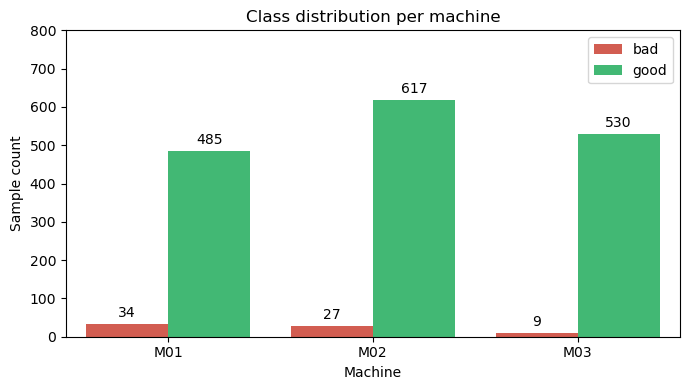

Global imbalance — good: 1632 (95.89% good) | Bad: 70 (4.11% bad)


In [ ]:
summary_machine = df.groupby(["machine", "label"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=summary_machine, x="machine", y="count", hue="label",
            palette=PALETTE, ax=ax) 

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3) 
    
ax.set_ylim(0, 800)
ax.set_title("Class distribution per machine")
ax.set_xlabel("Machine")
ax.set_ylabel("Sample count")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

ratio = df["label"].value_counts()
print(f"Global imbalance — good: {ratio['good']} ({ratio['good']/len(df):.2%} good) | Bad: {ratio['bad']} ({ratio['bad']/len(df):.2%} bad)")

~4% bad samples globally — severe class imbalance. M01 carries the most (34 bad), M03 the fewest (9),
which means the machine-out test set (M03) has very limited bad examples to evaluate on.
Process-level breakdown is omitted — labels are anonymized and shuffled per machine, so bad rates
per process carry no transferable meaning.

**Decision:** class weights + SMOTE applied to training data only.